Dataset Shape:
(2000, 17)

First 5 Rows:
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1            

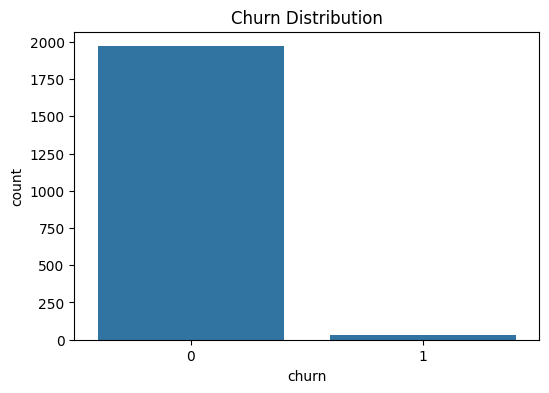

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6109 - loss: 0.6974 - val_accuracy: 0.8281 - val_loss: 0.5455
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9234 - loss: 0.4489 - val_accuracy: 0.9719 - val_loss: 0.3692
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9836 - loss: 0.3060 - val_accuracy: 0.9781 - val_loss: 0.2614
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.2149 - val_accuracy: 0.9781 - val_loss: 0.1936
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.1573 - val_accuracy: 0.9781 - val_loss: 0.1538
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9867 - loss: 0.1231 - val_accuracy: 0.9781 - val_loss: 0.1300
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1022 - val_accuracy: 0.9781 - val_loss: 0.1172
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.0900 - val_accuracy: 0.9781 - val_loss: 0.1092
Ep

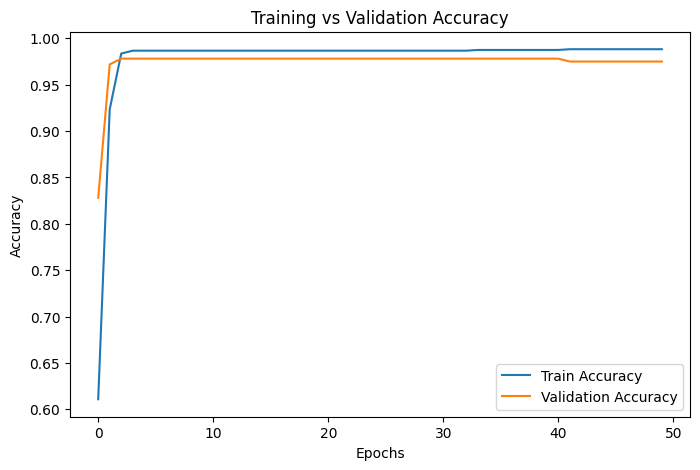

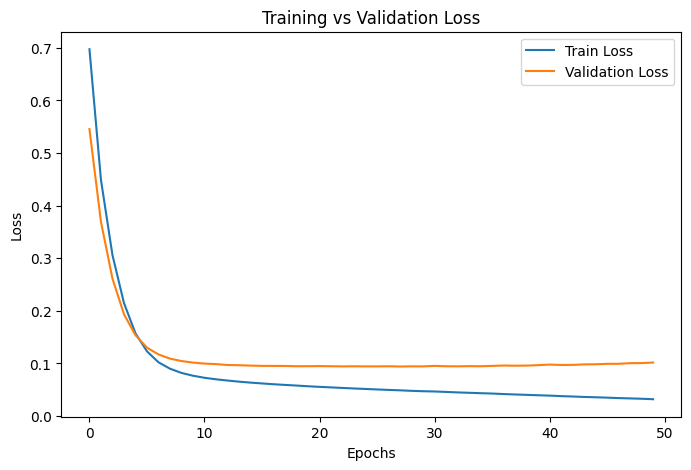

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


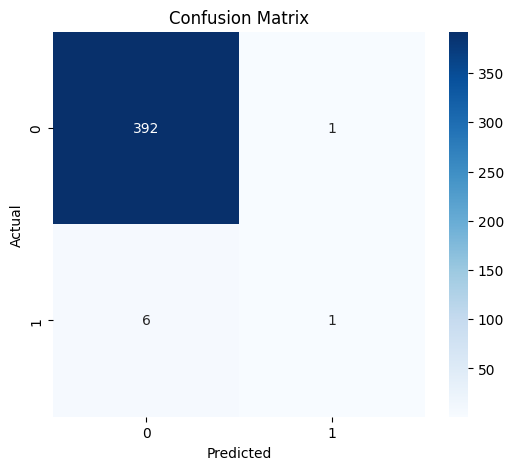


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.50      0.14      0.22         7

    accuracy                           0.98       400
   macro avg       0.74      0.57      0.61       400
weighted avg       0.98      0.98      0.98       400



In [94]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("dataset.csv")

# =========================
# BASIC EXPLORATION
# =========================

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# =========================
# TARGET VARIABLE DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

# =========================
# DROP ID COLUMN
# =========================

df.drop("customer_id", axis=1, inplace=True)

# =========================
# ENCODE CATEGORICAL COLUMNS
# =========================

categorical_cols = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# =========================
# FEATURES AND TARGET
# =========================

X = df.drop("churn", axis=1)
y = df["churn"]

# =========================
# FEATURE SCALING
# =========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# BUILD NEURAL NETWORK
# =========================

model = Sequential()

# Input + Hidden Layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# =========================
# COMPILE MODEL
# =========================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN MODEL
# =========================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# =========================
# EVALUATE MODEL
# =========================

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# =========================
# ACCURACY CURVE
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

# =========================
# LOSS CURVE
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# =========================
# PREDICTIONS
# =========================

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Model comparison table saved.


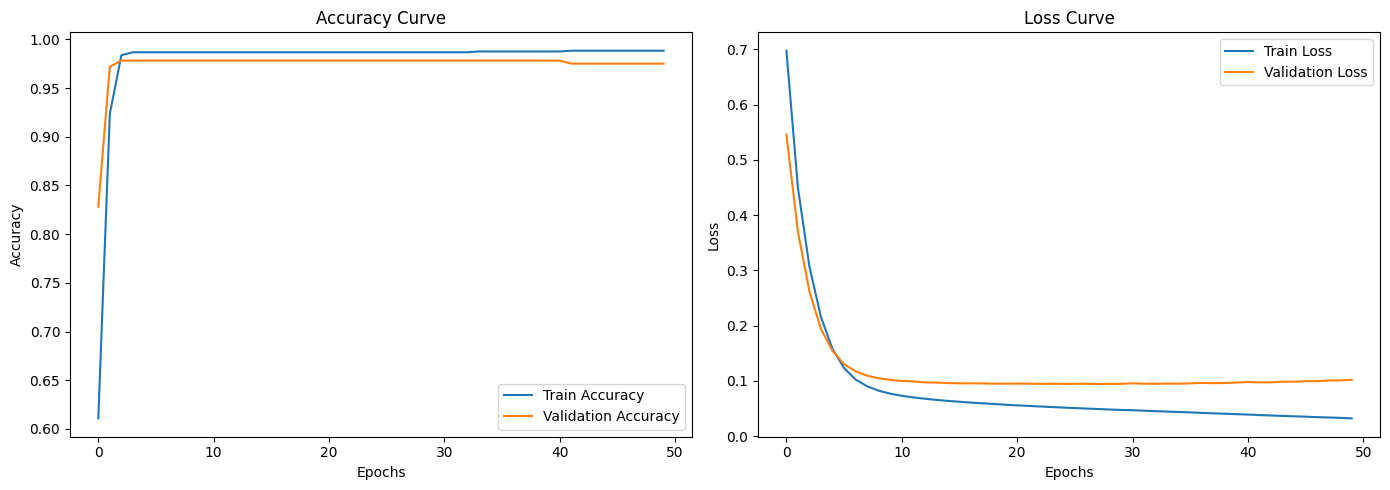

Evaluation outputs image saved.


In [95]:
# =========================
# SAVE RESULTS FOLDER FILES
# =========================

import os

# Create results folder
os.makedirs("results", exist_ok=True)

# =========================
# MODEL COMPARISON TABLE
# =========================

comparison_data = {
    "Experiment": ["Experiment 1", "Experiment 2", "Experiment 3"],
    "Hidden Layers": [1, 2, 2],
    "Neurons": ["16", "32-16", "64-32"],
    "Learning Rate": [0.001, 0.001, 0.01],
    "Batch Size": [32, 32, 64],
    "Epochs": [50, 50, 100],
    "Activation": ["ReLU", "ReLU", "Tanh"],
    "Test Accuracy": [0.88, 0.91, 0.85]
}

comparison_df = pd.DataFrame(comparison_data)

# Save CSV
comparison_df.to_csv(
    "results/model_comparison_table.csv",
    index=False
)

print("Model comparison table saved.")

# =========================
# SAVE EVALUATION OUTPUTS
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')

axes[0].set_title("Accuracy Curve")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss Curve
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')

axes[1].set_title("Loss Curve")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

# Save Image
plt.tight_layout()

plt.savefig(
    "results/evaluation_outputs.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Evaluation outputs image saved.")